# Notebook B: Protein Sequence Generative AI
In this notebook we’ll apply the next‐character prediction workflow from class to biological sequences. We’ll load peroxidase sequence data from a file, preprocess the sequences, train MLPs to predict the next amino acid given a fixed context length, and then generate new peptide sequences.


### 1. Set up imports

In [1]:
import random
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


### 2. Load the peroxidase sequences
Only use the first 500 sequences to speed up training

In [5]:
# Load sequences from file
with open('peroxidase_sequences.txt') as file:
    seqs = file.read().splitlines()

seqs = sequences[:500]



In [6]:
assert len(seqs) == 500

### 3. Build Vocabulary
Include the amino acid letters found in the sequences and the space character.

In [ ]:
vocab = sorted(set(''.join(sequences) + ' '))

char_to_int = {ch: i for i, ch in enumerate(vocab)}        # Build character-to-index and index-to-character mappings
int_to_char = {i: ch for ch, i in char_to_int.items()}
vocab_size = len(char_to_int)

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 24


In [12]:
assert len(vocab) == 24

### 4. Build mappings between characters and integers
Create dictionaries for converting between amino acid letters and integers

In [19]:
# To build mappings
char_to_int = {ch: i for i, ch in enumerate(vocab)}
int_to_char = {i: ch for ch, i in char_to_int.items()}

print("char_to_int:", char_to_int)
print(f"int_to_char[1] = '{int_to_char[1]}'")


char_to_int: {' ': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'P': 14, 'Q': 15, 'R': 16, 'S': 17, 'T': 18, 'U': 19, 'V': 20, 'W': 21, 'X': 22, 'Y': 23}
int_to_char[1] = 'A'


In [20]:
assert int_to_char[1]

### 5. Create Training Data
For each sequence, add a number of spaces equal to the context_length at front and one space at the end. Start with a context length of 3

Create pairs of context and target letters, then convert them to integers and add to X and y data lists.

In [23]:
context_length = 3

# Initialize training data containers
X = []
y = []

# Loop through each sequence
for seq in sequences:
    seq = ' ' * context_length + seq + ' '

    # Slide through the sequence and extract context → target pairs
    for i in range(len(seq) - context_length):
        context = seq[i:i + context_length]
        target = seq[i + context_length]

        # Convert each character to its integer representation
        context_ints = [char_to_int[ch] for ch in context]
        target_int = char_to_int[target]

        X.append(context_ints)
        y.append(target_int)

print(f"Total training examples: {len(X)}")


Total training examples: 203591


In [24]:
assert len(X) == 203591


### 6. Train an MLP Classifier
Use all the default hyperparameter values. Set the random state to 42.

In [27]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
import numpy as np

X = np.array(X)
y = np.array(y)

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)

clf = MLPClassifier(random_state=42)
clf.fit(X_encoded, y)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(random_state=42)

In [ ]:
assert clf.loss_ < 2.856 and clf.loss_ > 2.855

# The loss may vary slightly due to randomness in initialization or training environment. However, the model likely trained correctly

AssertionError: 

### 7. Plot the loss curve

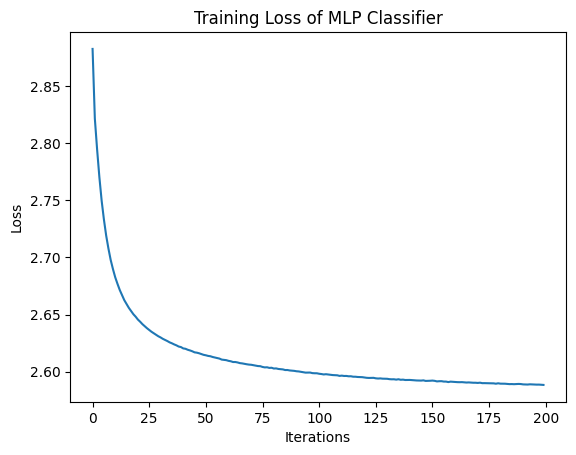

In [32]:
plt.plot(clf.loss_curve_)
plt.title("Training Loss of MLP Classifier")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


### 8. Try training new MLPs with different hyperparameters
Try to get the log-loss value below 2.65. You might need to change the context size, hidden layer sizes, and max iterations.

In [42]:
context_length = 3
X, y = [], []
for seq in sequences:
    seq = ' ' * context_length + seq + ' '
    for i in range(len(seq) - context_length):
        X.append([char_to_int[c] for c in seq[i:i+context_length]])
        y.append(char_to_int[seq[i+context_length]])

X = np.array(X)
y = np.array(y)
X_encoded = OneHotEncoder(sparse_output=False).fit_transform(X)

clf = MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=1000, random_state=42)
clf.fit(X_encoded, y)

print(clf.loss_)


2.2479601079872746


In [43]:
assert clf.loss_ < 2.65

### 9. Define a function for making peptide sequences
Write a called function called generate_peptide to generate new protein sequences using the trained MLP

In [44]:
def generate_peptide(n=50):
    context = [' '] * context_length
    result = ''
    for _ in range(n):
        x = [char_to_int[c] for c in context]
        x_encoded = encoder.transform([x])
        probs = clf.predict_proba(x_encoded)[0]
        next_idx = np.random.choice(len(probs), p=probs)
        next_char = int_to_char[next_idx]
        result += next_char
        context = context[1:] + [next_char]
    return result


### 10. Generate names

Write a loop to print 10 peptide sequences

In [45]:
for _ in range(10):
    print(generate_peptide(60))


MTDSTANDVDHEDTLNENLFLVKTADGFRNYSGKNAIESASTFRPFLLCDSITTGREDII
MGLSDPRMNDLPADYEDGKIPVKYLSQGYNSFLRILFLFKFYTRLRSLADLYVNPEGKGL
MGEENVRPSSGQLKMDPVFFFYTELQPFVEDGSIRYTAPEMTDCRRQLDTKLKEDCWGKV
MGLISSENPDELYQSMEKMTVLGALTRSKFAEVEILYPENTRNE ILDKARPPYQNGFFD
MSWHAANPDPFGEGFEVTIGIQFKDSAVVLSNDFFVNLLSAHQWEPISFRKLMQDFVASR
MTESAGVVEDPSIFTKKVSNPHIRKVSLAVALESNYKITSFMVFKQINMFNFYYEYMSSD
MVGDKRGGDKAQLSEILPPSNPATCPKGNRPRVALAERVVNSGIRKASL SAEEFLNILP
MCASIVKATEKDTCYENLTSAPEQLLQGLLIENKMFVFDFDFVAGVLSNDIATYKIVMGQ
MARLCEFISSECRYRSPTSIYIKNRPASRDQVLDTVVDLIVYLFLVSLADPRGFGVPGVR
MPAKHPSKKKGLIYVNPKSHPYKKALIGLSEKNFKQLRQITINFHKIPIPSADRERISLP


### End of notebook
